[*********************100%***********************]  1 of 1 completed


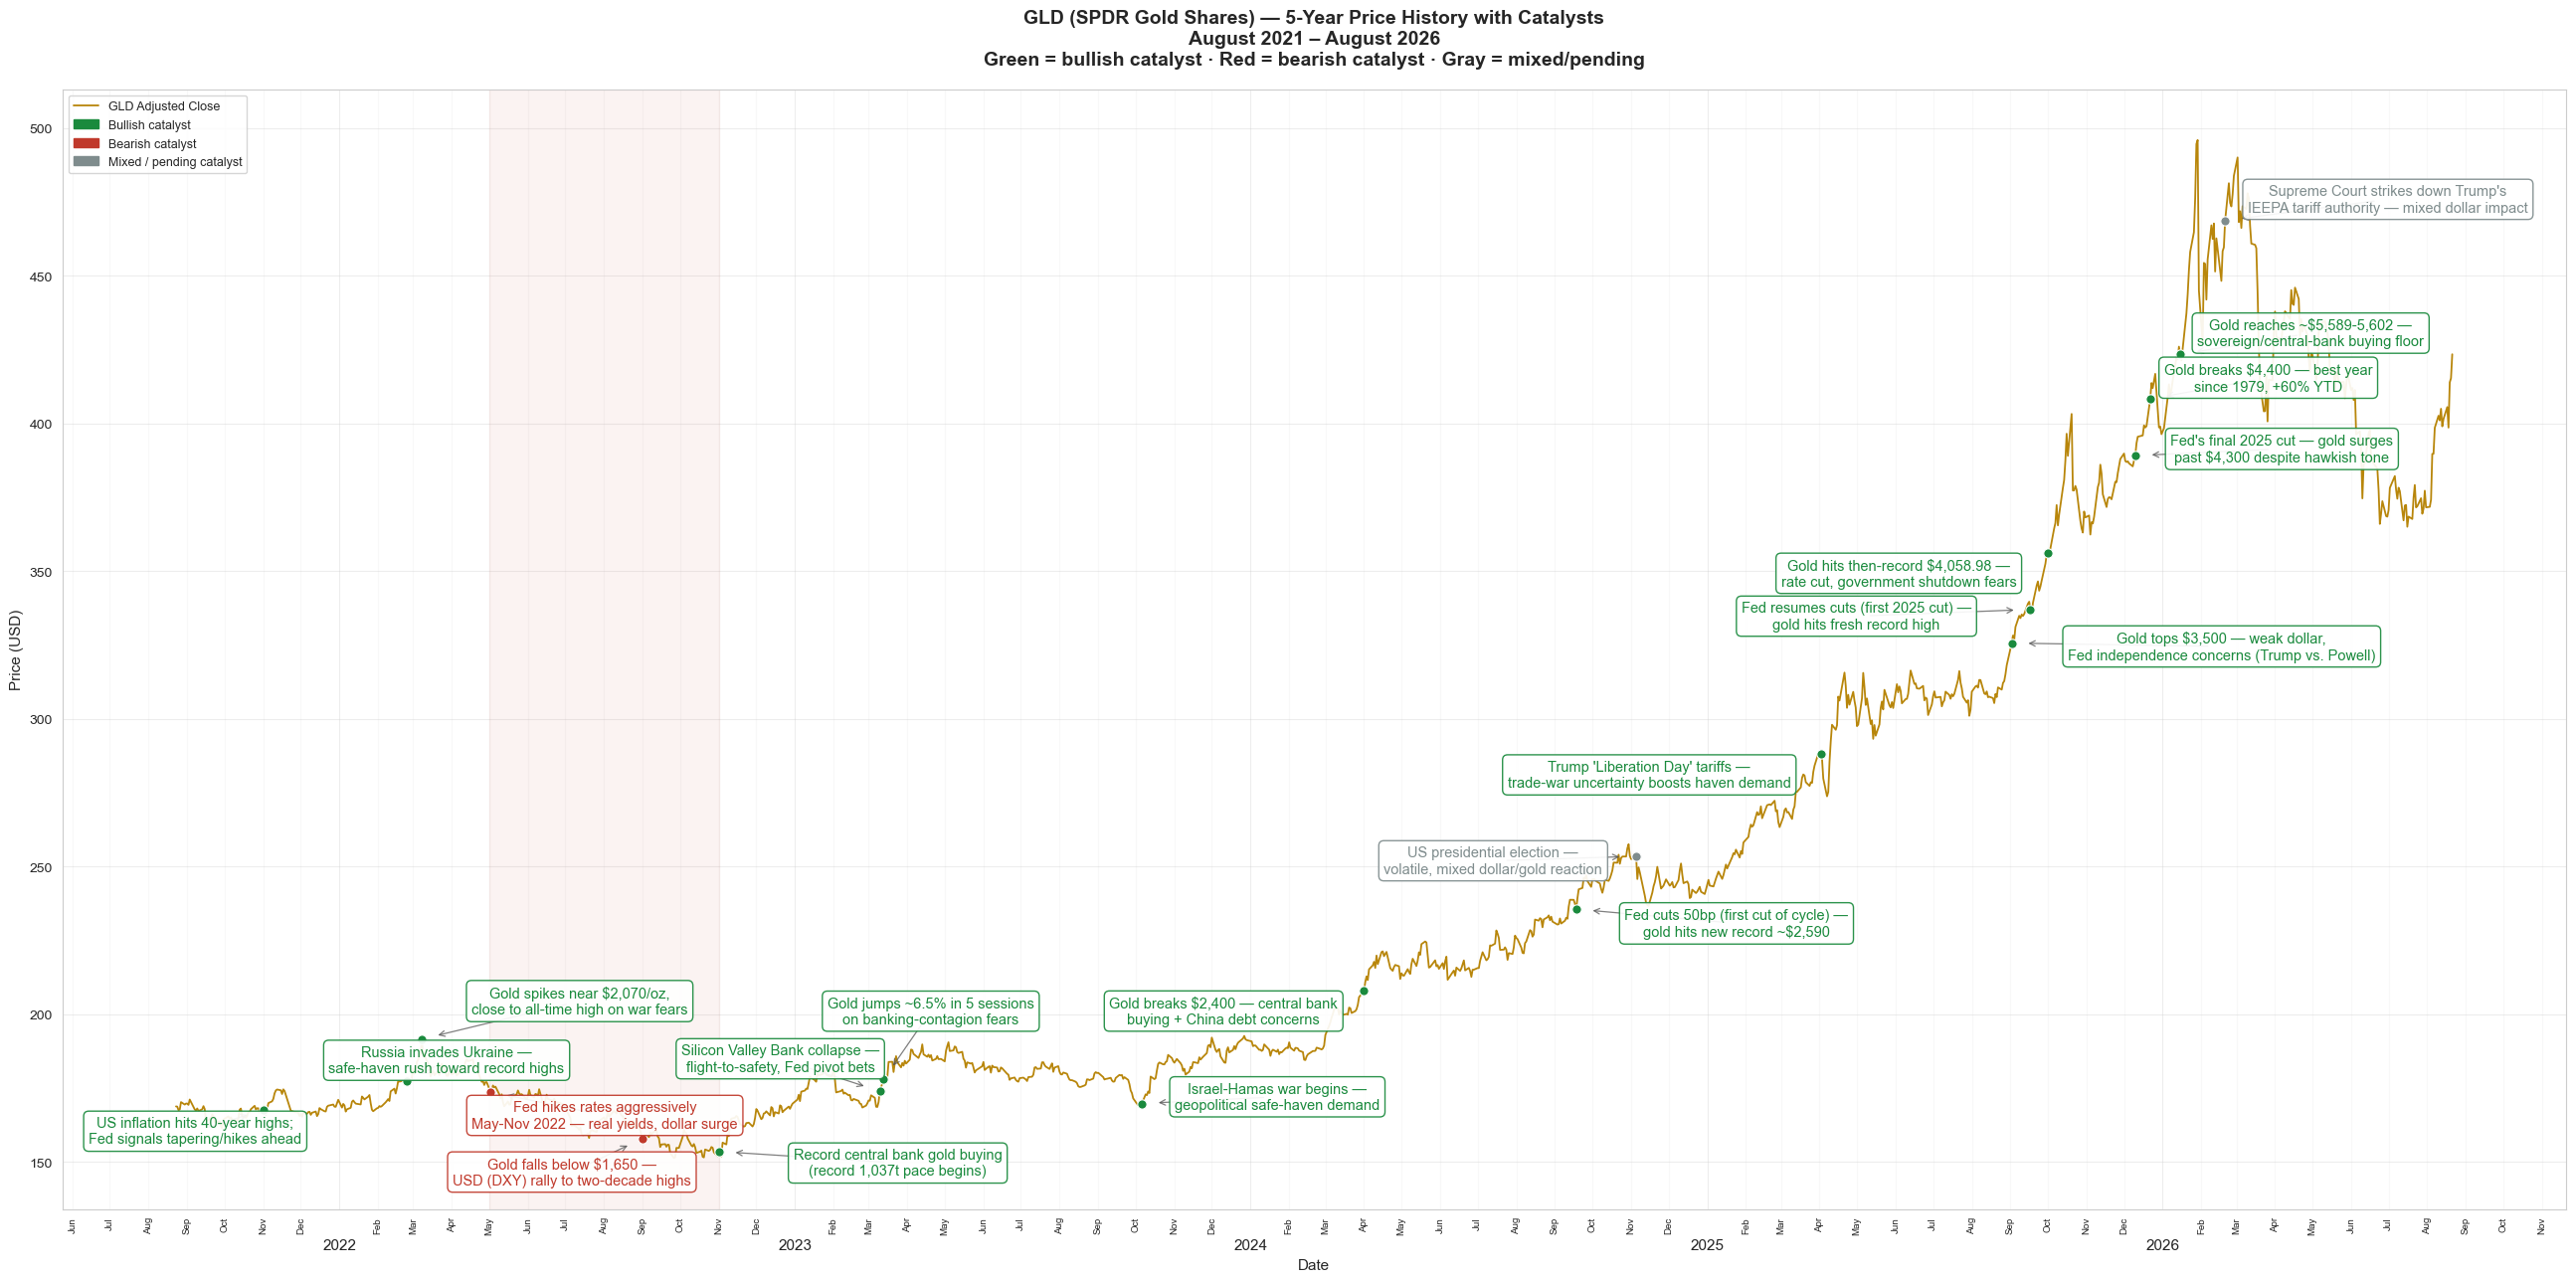

Data range: 2021-08-23 to 2026-08-21
Price range: $151.23 - $495.90
Total catalysts plotted: 20


In [3]:
"""
GLD (SPDR Gold Shares) — 5-Year Retrospective Catalyst Chart
====================================================================
Fetches 5 years of daily adjusted-close price data for GLD via yfinance
and plots it with annotated callouts marking the major macroeconomic,
geopolitical, and monetary-policy catalysts that moved gold from 2021-2026.

Color coding:
    GREEN = catalyst that was bullish (price-positive) for gold / GLD
    RED   = catalyst that was bearish (price-negative) for gold / GLD
    GRAY  = mixed / uncertain / pending catalyst (direction not clean either way)

Overlap handling:
    Annotation labels are placed with the `adjustText` library, which
    automatically repels text boxes away from each other and from the
    data points, then draws a connector line from each label back to
    its correct point on the price line. This keeps dense clusters of
    catalysts (e.g. late 2025's repeated record-high days) from overlapping.

Requirements:
    pip install yfinance matplotlib seaborn pandas adjustText

Note: Not executed in this environment (no network access here) —
run locally and re-check spacing once you see the real price scale
and label layout adjustText settles on.
"""

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns

try:
    from adjustText import adjust_text
except ImportError as e:
    raise ImportError(
        "This script requires the 'adjustText' package to prevent label "
        "overlap. Install it with: pip install adjustText"
    ) from e

# ----------------------------------------------------------------------
# 1. Fetch data
# ----------------------------------------------------------------------
TICKER = "GLD"
PERIOD_YEARS = 5

df = yf.download(TICKER, period=f"{PERIOD_YEARS}y", interval="1d", auto_adjust=True)
df = df.dropna()

if df.empty:
    raise RuntimeError(
        f"No data returned for {TICKER}. Check ticker validity and network connection."
    )

# Flatten MultiIndex columns if yfinance returns them (common with single-ticker downloads)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

price_col = "Close"  # auto_adjust=True makes 'Close' the adjusted close

# ----------------------------------------------------------------------
# 2. Define catalyst annotations
# ----------------------------------------------------------------------
# Each entry: (date_str, label, direction, shaded_span_or_None)
# direction: "positive" -> green (bullish for gold), "negative" -> red (bearish),
#            "neutral"  -> gray (mixed / pending)
DIRECTION_COLORS = {
    "positive": "#1a8a3d",   # green
    "negative": "#c0392b",   # red
    "neutral":  "#7f8c8d",   # gray
}

catalysts = [
    # --- 2021-22: inflation surge into the Fed hiking cycle ---
    ("2021-11-01", "US inflation hits 40-year highs;\nFed signals tapering/hikes ahead",
     "positive", None),

    # --- Feb-Mar 2022: Russia-Ukraine war spikes safe-haven demand ---
    ("2022-02-24", "Russia invades Ukraine —\nsafe-haven rush toward record highs",
     "positive", None),
    ("2022-03-08", "Gold spikes near $2,070/oz,\nclose to all-time high on war fears",
     "positive", None),

    # --- 2022: aggressive Fed hiking cycle pressures gold ---
    ("2022-05-01", "Fed hikes rates aggressively\nMay-Nov 2022 — real yields, dollar surge",
     "negative", ("2022-05-01", "2022-11-01")),
    ("2022-09-01", "Gold falls below $1,650 —\nUSD (DXY) rally to two-decade highs",
     "negative", None),

    # --- Late 2022-23: central bank buying floor ---
    ("2022-11-01", "Record central bank gold buying\n(record 1,037t pace begins)",
     "positive", None),

    # --- March 2023: SVB collapse / banking stress ---
    ("2023-03-10", "Silicon Valley Bank collapse —\nflight-to-safety, Fed pivot bets",
     "positive", None),
    ("2023-03-13", "Gold jumps ~6.5% in 5 sessions\non banking-contagion fears",
     "positive", None),

    # --- Oct 2023: Israel-Hamas war ---
    ("2023-10-07", "Israel-Hamas war begins —\ngeopolitical safe-haven demand",
     "positive", None),

    # --- 2024: multi-record rally on rate-cut expectations ---
    ("2024-04-01", "Gold breaks $2,400 — central bank\nbuying + China debt concerns",
     "positive", None),
    ("2024-09-18", "Fed cuts 50bp (first cut of cycle) —\ngold hits new record ~$2,590",
     "positive", None),
    ("2024-11-05", "US presidential election —\nvolatile, mixed dollar/gold reaction",
     "neutral", None),

    # --- 2025: tariff war, dollar weakness, record run ---
    ("2025-04-02", "Trump 'Liberation Day' tariffs —\ntrade-war uncertainty boosts haven demand",
     "positive", None),
    ("2025-09-02", "Gold tops $3,500 — weak dollar,\nFed independence concerns (Trump vs. Powell)",
     "positive", None),
    ("2025-09-17", "Fed resumes cuts (first 2025 cut) —\ngold hits fresh record high",
     "positive", None),
    ("2025-10-01", "Gold hits then-record $4,058.98 —\nrate cut, government shutdown fears",
     "positive", None),
    ("2025-12-10", "Fed's final 2025 cut — gold surges\npast $4,300 despite hawkish tone",
     "positive", None),
    ("2025-12-22", "Gold breaks $4,400 — best year\nsince 1979, +60% YTD",
     "positive", None),

    # --- 2026: continued record run ---
    ("2026-01-15", "Gold reaches ~$5,589-5,602 —\nsovereign/central-bank buying floor",
     "positive", None),
    ("2026-02-20", "Supreme Court strikes down Trump's\nIEEPA tariff authority — mixed dollar impact",
     "neutral", None),
]

# ----------------------------------------------------------------------
# 3. Plot
# ----------------------------------------------------------------------
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(26, 13))

ax.plot(df.index, df[price_col], color="#b8860b", linewidth=1.3, label=f"{TICKER} Adjusted Close", zorder=3)

text_objects = []
point_x_num = []
point_y = []

for date_str, label, direction, span in catalysts:
    date = pd.Timestamp(date_str)
    if date < df.index.min() or date > df.index.max():
        continue  # skip catalysts outside the fetched window

    color = DIRECTION_COLORS[direction]

    # Find nearest actual trading-day price for the marker
    nearest_idx = df.index.get_indexer([date], method="nearest")[0]
    nearest_date = df.index[nearest_idx]
    nearest_price = df[price_col].iloc[nearest_idx]
    x_num = mdates.date2num(nearest_date)

    # Marker dot at the true data point
    ax.scatter(nearest_date, nearest_price, color=color, s=45, zorder=5, edgecolor="white", linewidth=0.8)

    # Place text at a small initial offset near its point; adjustText will
    # move it to a clear spot and draw a connector back to (x_num, nearest_price)
    t = ax.text(
        x_num, nearest_price, label,
        fontsize=10.5, fontweight="medium", ha="center", va="center",
        color=color,
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec=color, alpha=0.92),
        zorder=6,
    )
    text_objects.append(t)
    point_x_num.append(x_num)
    point_y.append(nearest_price)

    # Optional shaded span (e.g. a multi-month hiking-cycle period)
    if span is not None:
        start, end = pd.Timestamp(span[0]), pd.Timestamp(span[1])
        ax.axvspan(start, end, color=color, alpha=0.06, zorder=1)

# Force a render pass so adjustText has a renderer available and can use
# FancyArrowPatch for connectors (avoids the "transform doesn't support
# FancyArrowPatch" fallback warning, whose arrows can strike through text).
fig.canvas.draw()

# Automatically resolve overlaps: repel labels from each other and from the
# price line's data points, then draw a connector line from each label back
# to its true point.
adjust_text(
    text_objects,
    x=point_x_num,
    y=point_y,
    ax=ax,
    expand_text=(1.15, 1.35),
    expand_points=(1.6, 1.8),
    force_text=(0.6, 1.1),
    force_points=(0.4, 0.6),
    arrowprops=dict(arrowstyle="->", color="#555555", lw=0.9, alpha=0.75, shrinkA=10, shrinkB=12),
)

# ----------------------------------------------------------------------
# 4. Formatting
# ----------------------------------------------------------------------
span_start = df.index.min().strftime("%B %Y")
span_end = df.index.max().strftime("%B %Y")

ax.set_title(
    f"{TICKER} (SPDR Gold Shares) — 5-Year Price History with Catalysts\n"
    f"{span_start} – {span_end}\n"
    "Green = bullish catalyst · Red = bearish catalyst · Gray = mixed/pending",
    fontsize=14, fontweight="bold", pad=18,
)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Price (USD)", fontsize=11)

# Major ticks = years, minor ticks = months, both labeled
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_minor_formatter(mdates.DateFormatter("%b"))

ax.tick_params(axis="x", which="minor", labelsize=7, rotation=90)
ax.tick_params(axis="x", which="major", labelsize=11, pad=18)

# Custom legend: price line + direction color key
price_handle = plt.Line2D([0], [0], color="#b8860b", lw=1.3, label=f"{TICKER} Adjusted Close")
pos_patch = mpatches.Patch(color=DIRECTION_COLORS["positive"], label="Bullish catalyst")
neg_patch = mpatches.Patch(color=DIRECTION_COLORS["negative"], label="Bearish catalyst")
neu_patch = mpatches.Patch(color=DIRECTION_COLORS["neutral"], label="Mixed / pending catalyst")
ax.legend(handles=[price_handle, pos_patch, neg_patch, neu_patch], loc="upper left", fontsize=9)

ax.grid(True, which="major", axis="both", alpha=0.35)
ax.grid(True, which="minor", axis="x", alpha=0.12)

plt.tight_layout()
plt.savefig("gld_5yr_catalyst_chart.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Data range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Price range: ${df[price_col].min():.2f} - ${df[price_col].max():.2f}")
print(f"Total catalysts plotted: {len(text_objects)}")

[*********************100%***********************]  1 of 1 completed


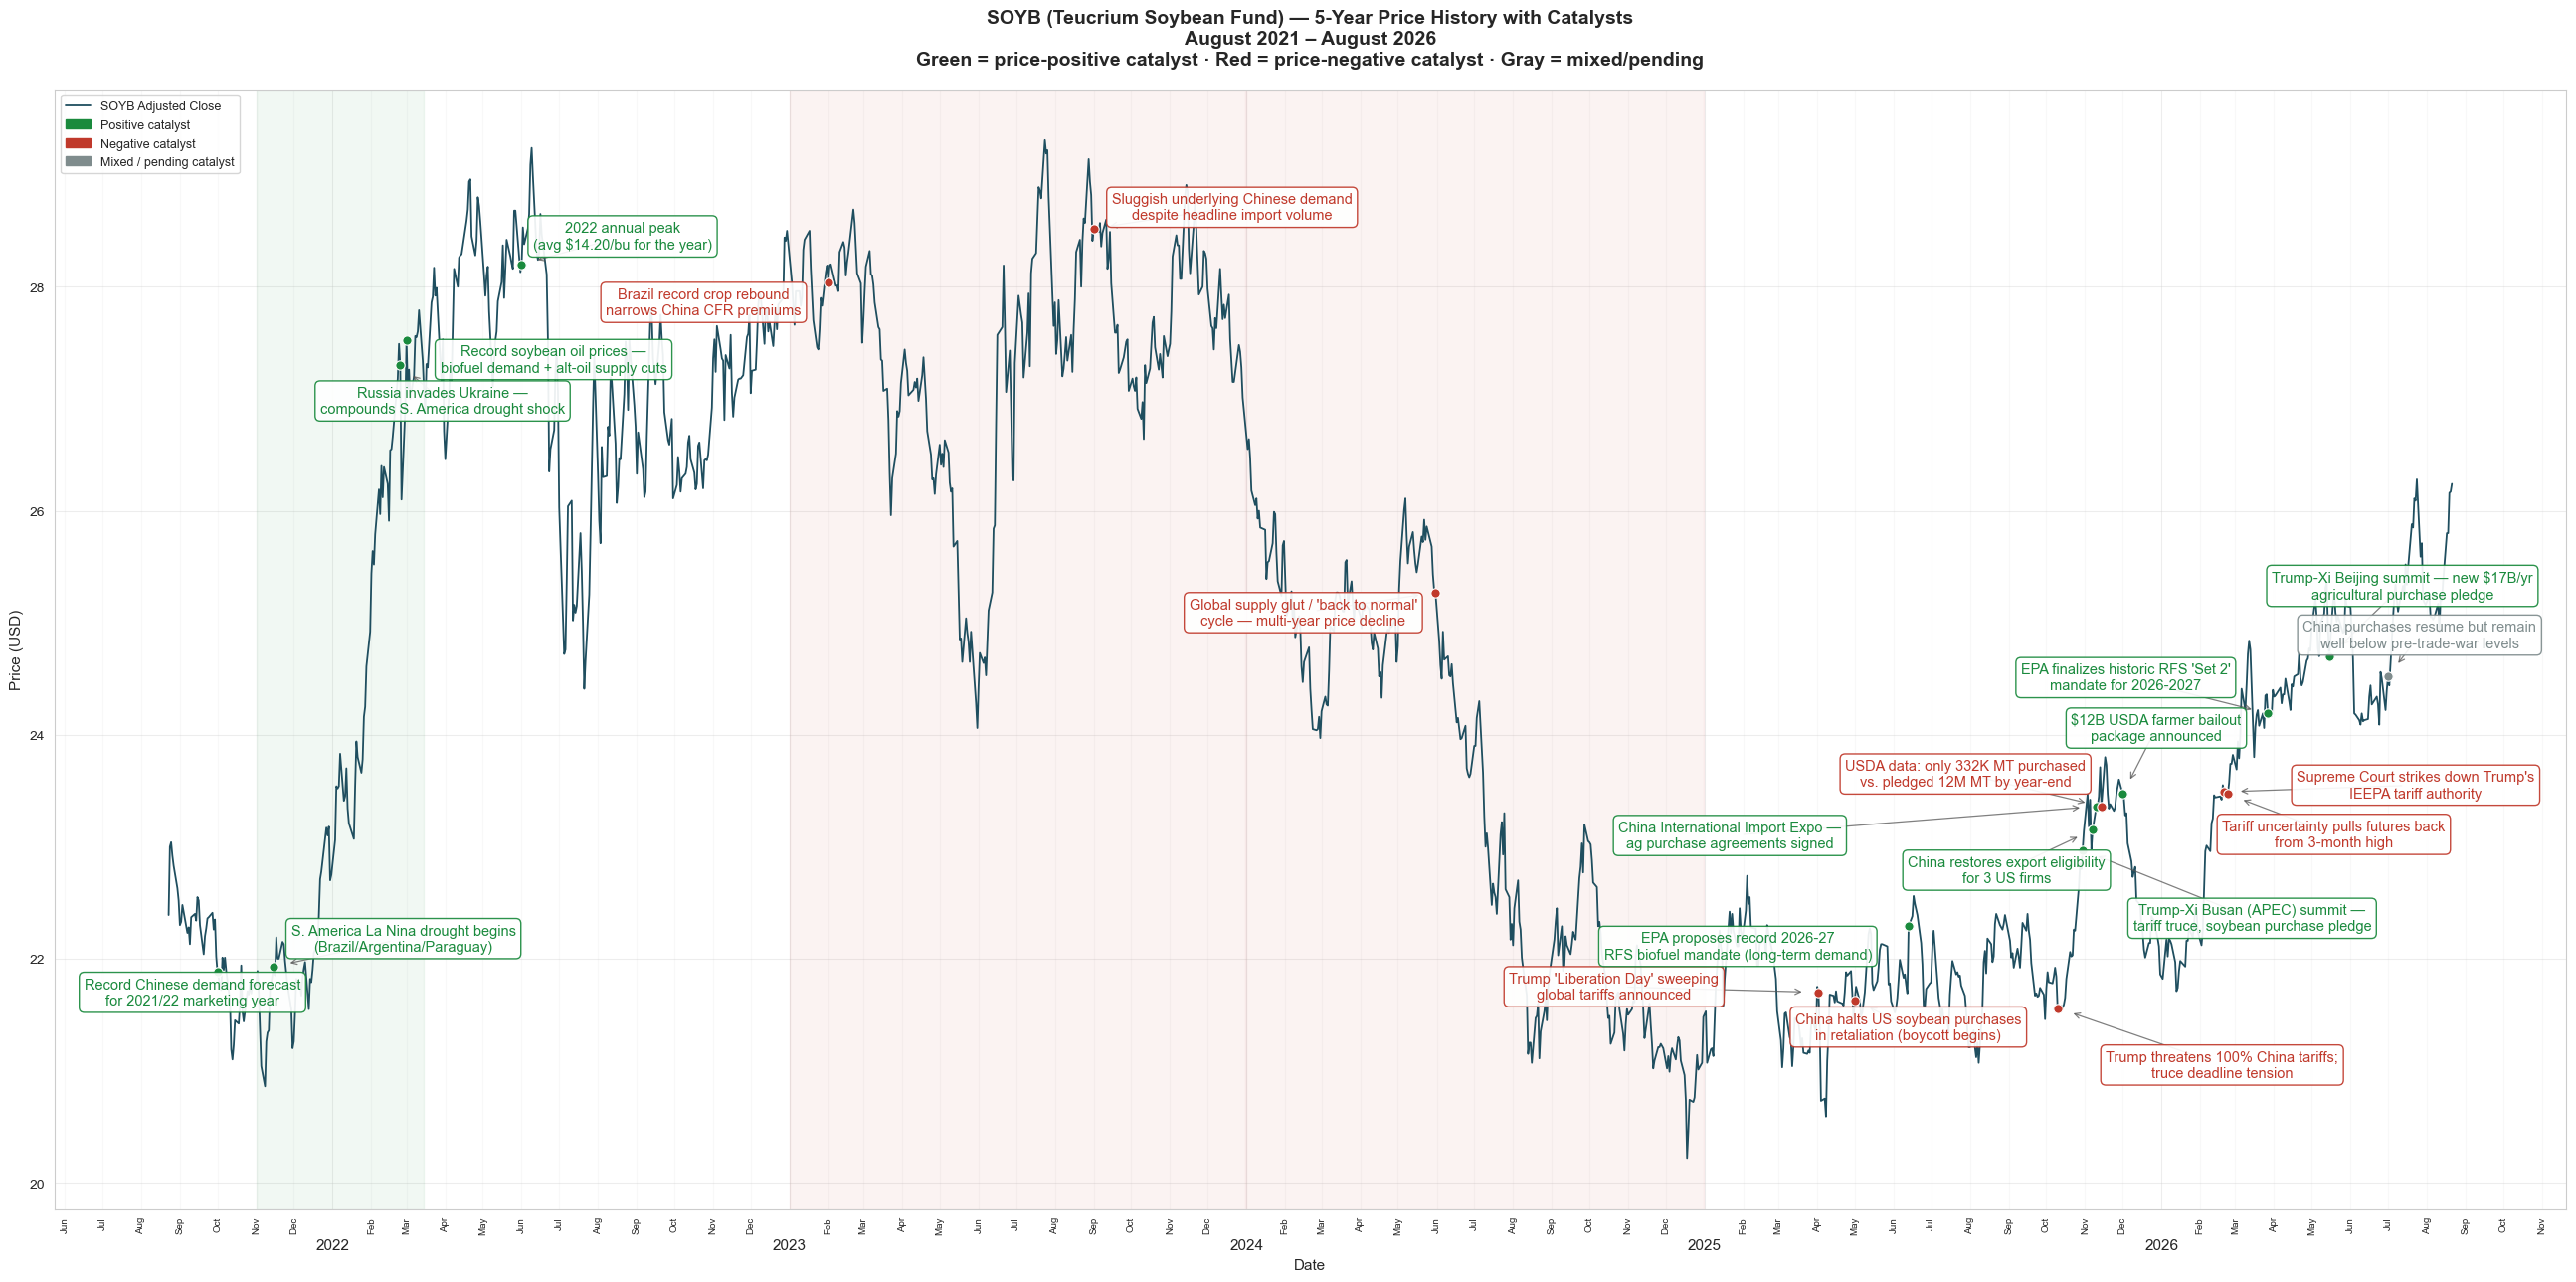

Data range: 2021-08-23 to 2026-08-21
Price range: $20.22 - $29.31
Total catalysts plotted: 22


In [2]:
"""
SOYB (Teucrium Soybean Fund) — 5-Year Retrospective Catalyst Chart
====================================================================
Fetches 5 years of daily adjusted-close price data for SOYB via yfinance
and plots it with annotated callouts marking the major macro / geopolitical
/ climate catalysts researched for the period (2021-2026).

Color coding:
    GREEN = catalyst that was price-positive for soybeans / SOYB
    RED   = catalyst that was price-negative for soybeans / SOYB
    GRAY  = mixed / uncertain / pending catalyst (direction not yet resolved)

Overlap handling:
    Annotation labels are placed with the `adjustText` library, which
    automatically repels text boxes away from each other and from the
    data points, then draws a connector line from each label back to
    its correct point on the price line. This is what keeps dense
    clusters of catalysts (e.g. Oct-Dec 2025) from overlapping.

Requirements:
    pip install yfinance matplotlib seaborn pandas adjustText

Note: Not executed in this environment (no network access here) —
run locally and re-check spacing once you see the real price scale
and label layout adjustText settles on.
"""

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns

try:
    from adjustText import adjust_text
except ImportError as e:
    raise ImportError(
        "This script requires the 'adjustText' package to prevent label "
        "overlap. Install it with: pip install adjustText"
    ) from e

# ----------------------------------------------------------------------
# 1. Fetch data
# ----------------------------------------------------------------------
TICKER = "SOYB"
PERIOD_YEARS = 5

df = yf.download(TICKER, period=f"{PERIOD_YEARS}y", interval="1d", auto_adjust=True)
df = df.dropna()

if df.empty:
    raise RuntimeError(
        f"No data returned for {TICKER}. Check ticker validity and network connection."
    )

# Flatten MultiIndex columns if yfinance returns them (common with single-ticker downloads)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

price_col = "Close"  # auto_adjust=True makes 'Close' the adjusted close

# ----------------------------------------------------------------------
# 2. Define catalyst annotations
# ----------------------------------------------------------------------
# Each entry: (date_str, label, direction, shaded_span_or_None)
# direction: "positive" -> green, "negative" -> red, "neutral" -> gray
# (No manual y-offset needed anymore — adjustText positions labels automatically.)
DIRECTION_COLORS = {
    "positive": "#1a8a3d",   # green
    "negative": "#c0392b",   # red
    "neutral":  "#7f8c8d",   # gray
}

catalysts = [
    # --- 2021 ---
    ("2021-10-01", "Record Chinese demand forecast\nfor 2021/22 marketing year",
     "positive", None),

    # --- Late 2021 - early 2022: La Nina drought + Ukraine war ---
    ("2021-11-15", "S. America La Nina drought begins\n(Brazil/Argentina/Paraguay)",
     "positive", ("2021-11-01", "2022-03-15")),
    ("2022-02-24", "Russia invades Ukraine —\ncompounds S. America drought shock",
     "positive", None),
    ("2022-06-01", "2022 annual peak\n(avg $14.20/bu for the year)",
     "positive", None),

    # --- 2021-22: biofuel / soy oil ---
    ("2022-03-01", "Record soybean oil prices —\nbiofuel demand + alt-oil supply cuts",
     "positive", None),

    # --- 2023: Brazil rebound, weakening demand ---
    ("2023-02-01", "Brazil record crop rebound\nnarrows China CFR premiums",
     "negative", ("2023-01-01", "2023-12-31")),
    ("2023-09-01", "Sluggish underlying Chinese demand\ndespite headline import volume",
     "negative", None),

    # --- 2024: supply glut ---
    ("2024-06-01", "Global supply glut / 'back to normal'\ncycle — multi-year price decline",
     "negative", ("2024-01-01", "2024-12-31")),

    # --- 2025: tariff war ---
    ("2025-04-02", "Trump 'Liberation Day' sweeping\nglobal tariffs announced",
     "negative", None),
    ("2025-05-01", "China halts US soybean purchases\nin retaliation (boycott begins)",
     "negative", None),
    ("2025-06-13", "EPA proposes record 2026-27\nRFS biofuel mandate (long-term demand)",
     "positive", None),
    ("2025-10-10", "Trump threatens 100% China tariffs;\ntruce deadline tension",
     "negative", None),
    ("2025-10-30", "Trump-Xi Busan (APEC) summit —\ntariff truce, soybean purchase pledge",
     "positive", None),
    ("2025-11-07", "China restores export eligibility\nfor 3 US firms",
     "positive", None),
    ("2025-11-10", "China International Import Expo —\nag purchase agreements signed",
     "positive", None),
    ("2025-11-14", "USDA data: only 332K MT purchased\nvs. pledged 12M MT by year-end",
     "negative", None),
    ("2025-12-01", "$12B USDA farmer bailout\npackage announced",
     "positive", None),

    # --- 2026 ---
    ("2026-02-20", "Supreme Court strikes down Trump's\nIEEPA tariff authority",
     "negative", None),
    ("2026-02-23", "Tariff uncertainty pulls futures back\nfrom 3-month high",
     "negative", None),
    ("2026-03-27", "EPA finalizes historic RFS 'Set 2'\nmandate for 2026-2027",
     "positive", None),
    ("2026-05-15", "Trump-Xi Beijing summit — new $17B/yr\nagricultural purchase pledge",
     "positive", None),
    ("2026-07-01", "China purchases resume but remain\nwell below pre-trade-war levels",
     "neutral", None),
    ("2026-09-24", "Xi Jinping state visit — Trump meeting\n(pending, inside competition window)",
     "neutral", None),
]

# ----------------------------------------------------------------------
# 3. Plot
# ----------------------------------------------------------------------
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(26, 13))

ax.plot(df.index, df[price_col], color="#1f4e5f", linewidth=1.3, label=f"{TICKER} Adjusted Close", zorder=3)

text_objects = []
point_x_num = []
point_y = []

for date_str, label, direction, span in catalysts:
    date = pd.Timestamp(date_str)
    if date < df.index.min() or date > df.index.max():
        continue  # skip catalysts outside the fetched window

    color = DIRECTION_COLORS[direction]

    # Find nearest actual trading-day price for the marker
    nearest_idx = df.index.get_indexer([date], method="nearest")[0]
    nearest_date = df.index[nearest_idx]
    nearest_price = df[price_col].iloc[nearest_idx]
    x_num = mdates.date2num(nearest_date)

    # Marker dot at the true data point
    ax.scatter(nearest_date, nearest_price, color=color, s=45, zorder=5, edgecolor="white", linewidth=0.8)

    # Place text at a small initial offset near its point; adjustText will
    # move it to a clear spot and draw a connector back to (x_num, nearest_price)
    t = ax.text(
        x_num, nearest_price, label,
        fontsize=10.5, fontweight="medium", ha="center", va="center",
        color=color,
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec=color, alpha=0.92),
        zorder=6,
    )
    text_objects.append(t)
    point_x_num.append(x_num)
    point_y.append(nearest_price)

    # Optional shaded span (e.g. a multi-month drought/glut period)
    if span is not None:
        start, end = pd.Timestamp(span[0]), pd.Timestamp(span[1])
        ax.axvspan(start, end, color=color, alpha=0.06, zorder=1)

# Force a render pass so adjustText has a renderer available and can use
# FancyArrowPatch for connectors (avoids the "transform doesn't support
# FancyArrowPatch" fallback warning, whose arrows can strike through text).
fig.canvas.draw()

# Automatically resolve overlaps: repel labels from each other and from the
# price line's data points, then draw a connector line from each label back
# to its true point.
adjust_text(
    text_objects,
    x=point_x_num,
    y=point_y,
    ax=ax,
    expand_text=(1.15, 1.35),
    expand_points=(1.6, 1.8),
    force_text=(0.6, 1.1),
    force_points=(0.4, 0.6),
    arrowprops=dict(arrowstyle="->", color="#555555", lw=0.9, alpha=0.75, shrinkA=10, shrinkB=12),
)

# ----------------------------------------------------------------------
# 4. Formatting
# ----------------------------------------------------------------------
span_start = df.index.min().strftime("%B %Y")
span_end = df.index.max().strftime("%B %Y")

ax.set_title(
    f"{TICKER} (Teucrium Soybean Fund) — 5-Year Price History with Catalysts\n"
    f"{span_start} – {span_end}\n"
    "Green = price-positive catalyst · Red = price-negative catalyst · Gray = mixed/pending",
    fontsize=14, fontweight="bold", pad=18,
)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Price (USD)", fontsize=11)

# Major ticks = years, minor ticks = months, both labeled
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_minor_formatter(mdates.DateFormatter("%b"))

ax.tick_params(axis="x", which="minor", labelsize=7, rotation=90)
ax.tick_params(axis="x", which="major", labelsize=11, pad=18)

# Custom legend: price line + direction color key
price_handle = plt.Line2D([0], [0], color="#1f4e5f", lw=1.3, label=f"{TICKER} Adjusted Close")
pos_patch = mpatches.Patch(color=DIRECTION_COLORS["positive"], label="Positive catalyst")
neg_patch = mpatches.Patch(color=DIRECTION_COLORS["negative"], label="Negative catalyst")
neu_patch = mpatches.Patch(color=DIRECTION_COLORS["neutral"], label="Mixed / pending catalyst")
ax.legend(handles=[price_handle, pos_patch, neg_patch, neu_patch], loc="upper left", fontsize=9)

ax.grid(True, which="major", axis="both", alpha=0.35)
ax.grid(True, which="minor", axis="x", alpha=0.12)

plt.tight_layout()
plt.savefig("soyb_5yr_catalyst_chart.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Data range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Price range: ${df[price_col].min():.2f} - ${df[price_col].max():.2f}")
print(f"Total catalysts plotted: {len(text_objects)}")

[*********************100%***********************]  1 of 1 completed


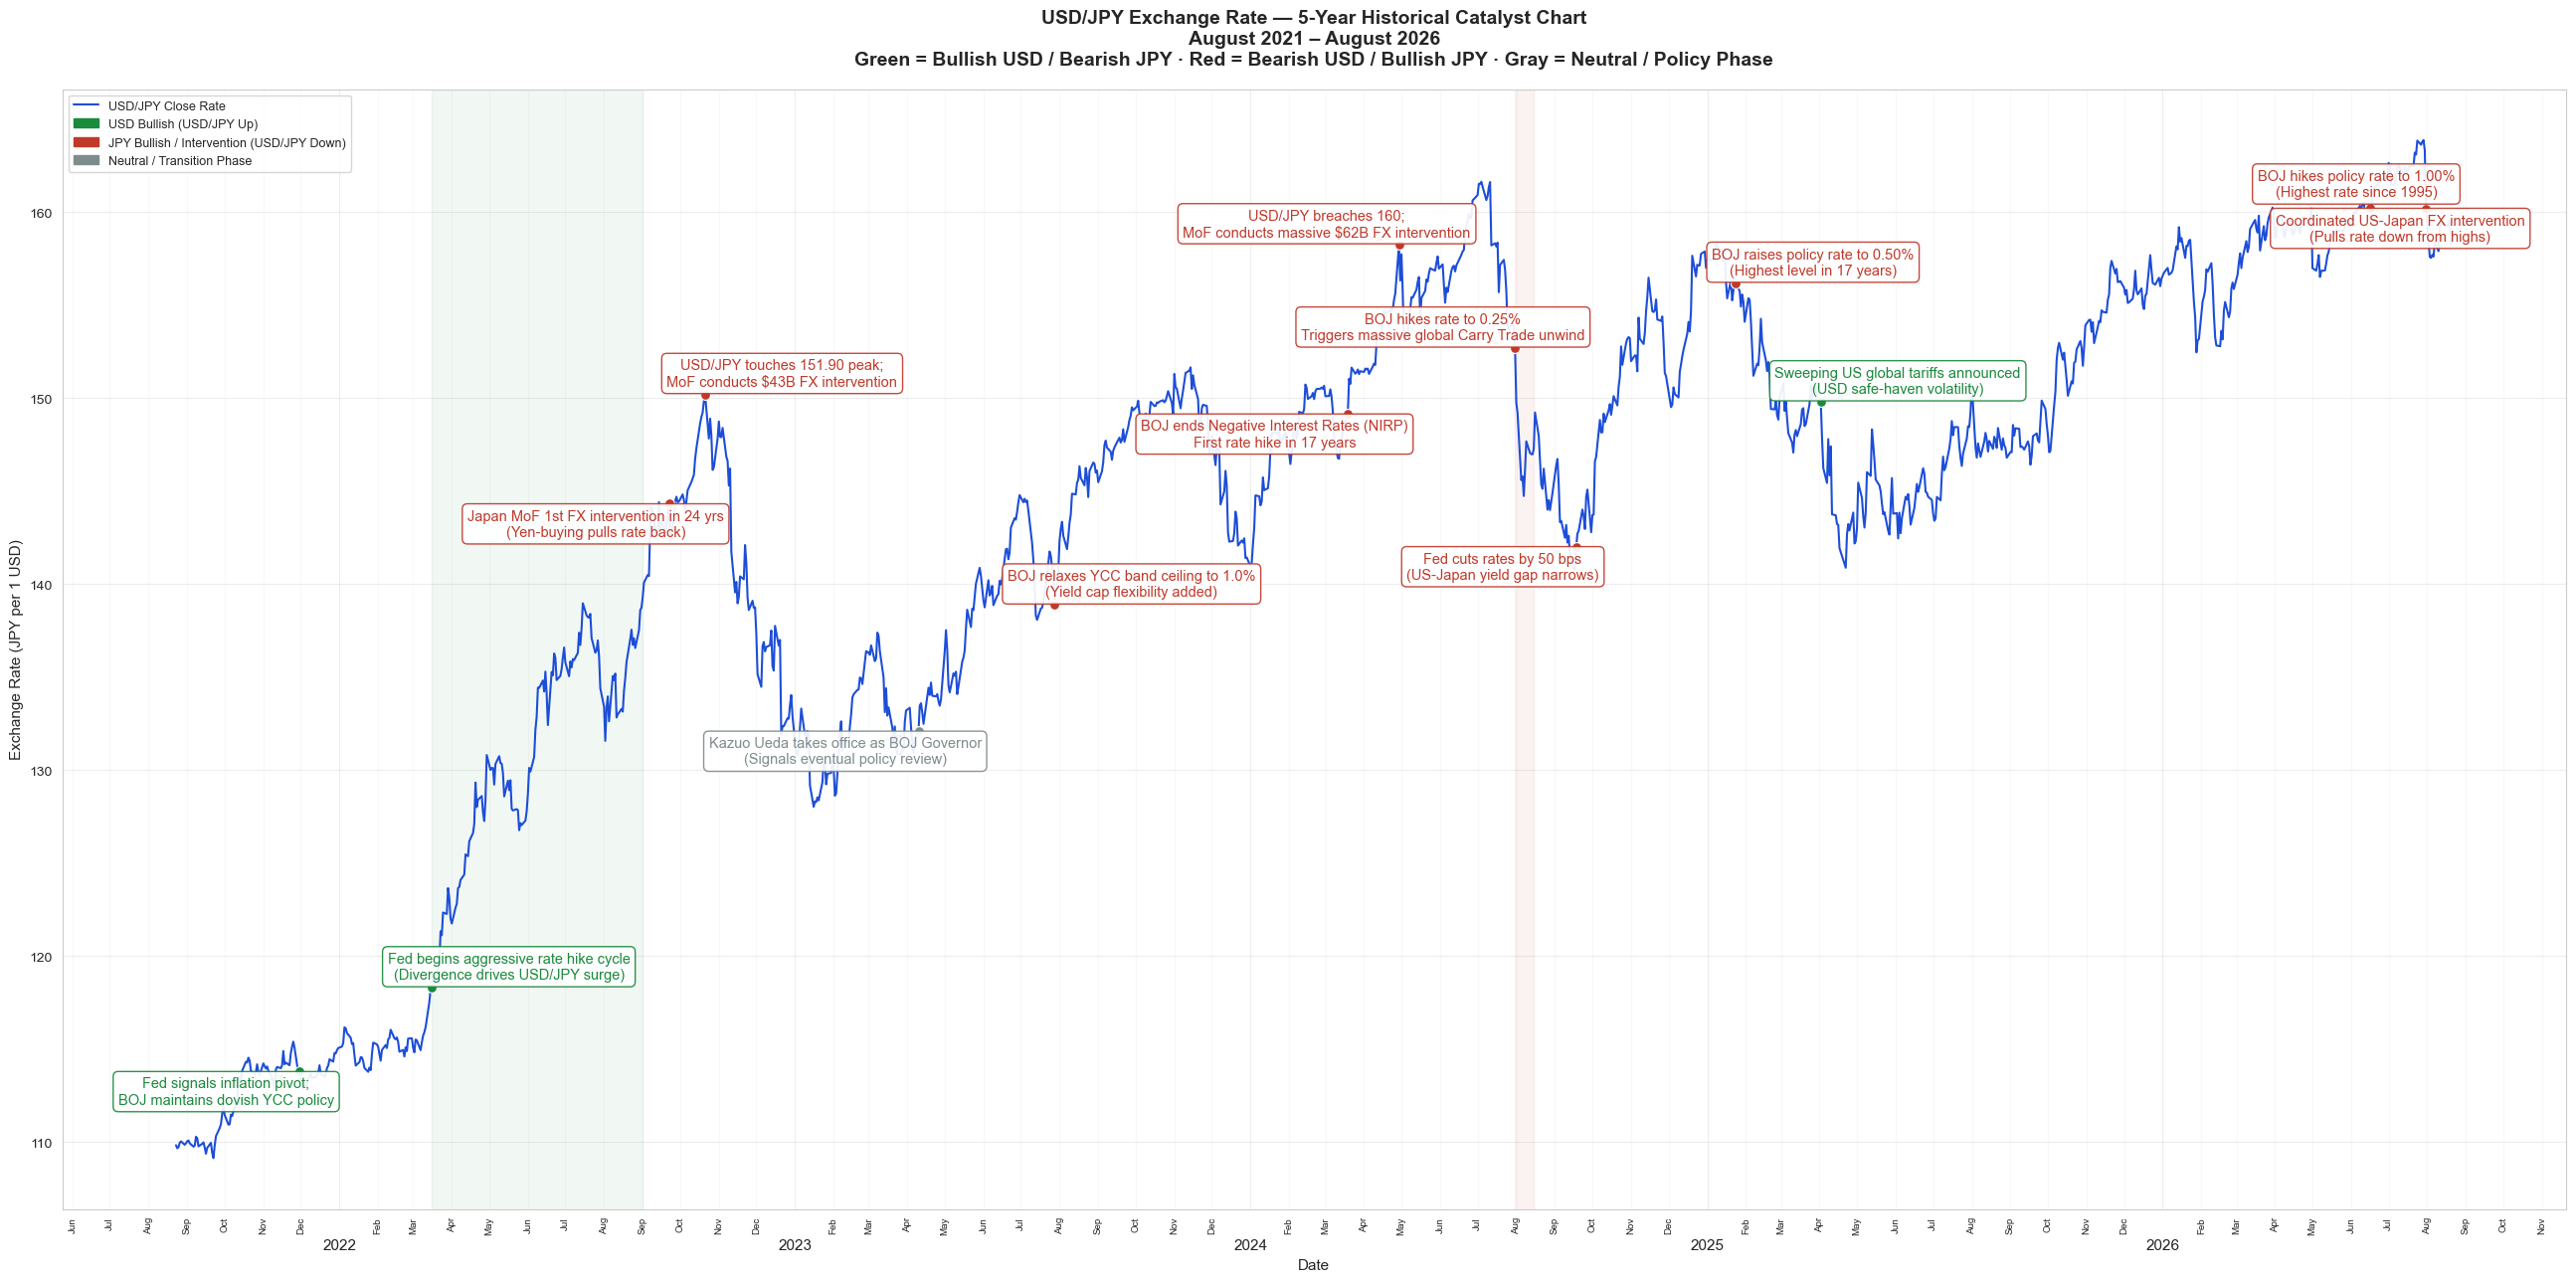

Data range: 2021-08-23 to 2026-08-21
Rate range: ¥109.15 - ¥163.86
Total catalysts plotted: 14


In [4]:
"""
USD/JPY (US Dollar / Japanese Yen) — 5-Year Retrospective Catalyst Chart
========================================================================
Fetches 5 years of daily close price data for USD/JPY (JPY=X) via yfinance
and plots it with annotated callouts marking major monetary policy shifts
(Fed/BOJ), MoF FX interventions, and carry trade unwinds (2021-2026).

Color coding:
    GREEN = USD strengthens / JPY weakens (USD/JPY moves UP)
    RED   = USD weakens / JPY strengthens (USD/JPY moves DOWN)
    GRAY  = Mixed / policy transition phase / neutral impact
"""

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns

try:
    from adjustText import adjust_text
except ImportError as e:
    raise ImportError(
        "This script requires the 'adjustText' package to prevent label "
        "overlap. Install it with: pip install adjustText"
    ) from e

# ----------------------------------------------------------------------
# 1. Fetch data
# ----------------------------------------------------------------------
TICKER = "JPY=X"
PERIOD_YEARS = 5

df = yf.download(TICKER, period=f"{PERIOD_YEARS}y", interval="1d", auto_adjust=True)
df = df.dropna()

if df.empty:
    raise RuntimeError(
        f"No data returned for {TICKER}. Check ticker validity and network connection."
    )

# Flatten MultiIndex columns if yfinance returns them
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

price_col = "Close"

# ----------------------------------------------------------------------
# 2. Define catalyst annotations
# ----------------------------------------------------------------------
DIRECTION_COLORS = {
    "positive": "#1a8a3d",   # green (USD Bullish / JPY Bearish)
    "negative": "#c0392b",   # red (USD Bearish / JPY Bullish)
    "neutral":  "#7f8c8d",   # gray (Mixed / Pending)
}

catalysts = [
    # --- 2021-2022: Fed vs. BOJ policy divergence begins ---
    ("2021-11-30", "Fed signals inflation pivot;\nBOJ maintains dovish YCC policy",
     "positive", None),
    ("2022-03-16", "Fed begins aggressive rate hike cycle\n(Divergence drives USD/JPY surge)",
     "positive", ("2022-03-16", "2022-09-01")),
     
    # --- Late 2022: MoF Interventions ---
    ("2022-09-22", "Japan MoF 1st FX intervention in 24 yrs\n(Yen-buying pulls rate back)",
     "negative", None),
    ("2022-10-21", "USD/JPY touches 151.90 peak;\nMoF conducts $43B FX intervention",
     "negative", None),

    # --- 2023: BOJ Leadership & YCC Adjustments ---
    ("2023-04-09", "Kazuo Ueda takes office as BOJ Governor\n(Signals eventual policy review)",
     "neutral", None),
    ("2023-07-28", "BOJ relaxes YCC band ceiling to 1.0%\n(Yield cap flexibility added)",
     "negative", None),

    # --- 2024: Historic BOJ Hikes & Carry Unwind ---
    ("2024-03-19", "BOJ ends Negative Interest Rates (NIRP)\nFirst rate hike in 17 years",
     "negative", None),
    ("2024-04-29", "USD/JPY breaches 160;\nMoF conducts massive $62B FX intervention",
     "negative", None),
    ("2024-07-31", "BOJ hikes rate to 0.25%\nTriggers massive global Carry Trade unwind",
     "negative", ("2024-07-31", "2024-08-15")),
    ("2024-09-18", "Fed cuts rates by 50 bps\n(US-Japan yield gap narrows)",
     "negative", None),

    # --- 2025: Continued BOJ Tightening & Macro Shifts ---
    ("2025-01-24", "BOJ raises policy rate to 0.50%\n(Highest level in 17 years)",
     "negative", None),
    ("2025-04-02", "Sweeping US global tariffs announced\n(USD safe-haven volatility)",
     "positive", None),

    # --- 2026: Joint Intervention & Policy Normalization ---
    ("2026-06-16", "BOJ hikes policy rate to 1.00%\n(Highest rate since 1995)",
     "negative", None),
    ("2026-07-31", "Coordinated US-Japan FX intervention\n(Pulls rate down from highs)",
     "negative", None),
]

# ----------------------------------------------------------------------
# 3. Plot
# ----------------------------------------------------------------------
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(26, 13))

ax.plot(df.index, df[price_col], color="#1d4ed8", linewidth=1.5, label="USD/JPY Exchange Rate", zorder=3)

text_objects = []
point_x_num = []
point_y = []

for date_str, label, direction, span in catalysts:
    date = pd.Timestamp(date_str)
    if date < df.index.min() or date > df.index.max():
        continue 

    color = DIRECTION_COLORS[direction]

    # Find nearest actual trading-day price for the marker
    nearest_idx = df.index.get_indexer([date], method="nearest")[0]
    nearest_date = df.index[nearest_idx]
    nearest_price = df[price_col].iloc[nearest_idx]
    x_num = mdates.date2num(nearest_date)

    ax.scatter(nearest_date, nearest_price, color=color, s=50, zorder=5, edgecolor="white", linewidth=0.8)

    t = ax.text(
        x_num, nearest_price, label,
        fontsize=10.5, fontweight="medium", ha="center", va="center",
        color=color,
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec=color, alpha=0.92),
        zorder=6,
    )
    text_objects.append(t)
    point_x_num.append(x_num)
    point_y.append(nearest_price)

    # Optional shaded span
    if span is not None:
        start, end = pd.Timestamp(span[0]), pd.Timestamp(span[1])
        ax.axvspan(start, end, color=color, alpha=0.06, zorder=1)

fig.canvas.draw()

# Automatically resolve overlaps
adjust_text(
    text_objects,
    x=point_x_num,
    y=point_y,
    ax=ax,
    expand_text=(1.15, 1.35),
    expand_points=(1.6, 1.8),
    force_text=(0.6, 1.1),
    force_points=(0.4, 0.6),
    arrowprops=dict(arrowstyle="->", color="#555555", lw=0.9, alpha=0.75, shrinkA=10, shrinkB=12),
)

# ----------------------------------------------------------------------
# 4. Formatting
# ----------------------------------------------------------------------
span_start = df.index.min().strftime("%B %Y")
span_end = df.index.max().strftime("%B %Y")

ax.set_title(
    f"USD/JPY Exchange Rate — 5-Year Historical Catalyst Chart\n"
    f"{span_start} – {span_end}\n"
    "Green = Bullish USD / Bearish JPY · Red = Bearish USD / Bullish JPY · Gray = Neutral / Policy Phase",
    fontsize=14, fontweight="bold", pad=18,
)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Exchange Rate (JPY per 1 USD)", fontsize=11)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_minor_formatter(mdates.DateFormatter("%b"))

ax.tick_params(axis="x", which="minor", labelsize=7, rotation=90)
ax.tick_params(axis="x", which="major", labelsize=11, pad=18)

# Custom legend
price_handle = plt.Line2D([0], [0], color="#1d4ed8", lw=1.5, label="USD/JPY Close Rate")
pos_patch = mpatches.Patch(color=DIRECTION_COLORS["positive"], label="USD Bullish (USD/JPY Up)")
neg_patch = mpatches.Patch(color=DIRECTION_COLORS["negative"], label="JPY Bullish / Intervention (USD/JPY Down)")
neu_patch = mpatches.Patch(color=DIRECTION_COLORS["neutral"], label="Neutral / Transition Phase")
ax.legend(handles=[price_handle, pos_patch, neg_patch, neu_patch], loc="upper left", fontsize=9)

ax.grid(True, which="major", axis="both", alpha=0.35)
ax.grid(True, which="minor", axis="x", alpha=0.12)

plt.tight_layout()
plt.savefig("usdjpy_5yr_catalyst_chart.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Data range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Rate range: ¥{df[price_col].min():.2f} - ¥{df[price_col].max():.2f}")
print(f"Total catalysts plotted: {len(text_objects)}")